In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch 
from scipy.stats import skew, kurtosis
import pywt
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import reservoirpy as rpy
rpy.set_seed(42)
from reservoirpy.nodes import Reservoir, Ridge

In [2]:
dataEMG = pd.read_csv('EMG_delimit.csv')
dataEIM = pd.read_csv('EIM_delimit.csv')

print(dataEMG.head())
print(dataEIM.head())

C:\Users\rehan\AppData\Local\Temp\ipykernel_16660\2719477067.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  dataEMG = pd.read_csv('EMG_delimit.csv')


       AMI Unnamed: 1      ANF Unnamed: 3      HFN Unnamed: 5      JDS  \
0      Pre       Post      Pre       Post      Pre       Post      Pre   
1  EMG (V)    EMG (V)  EMG (V)    EMG (V)  EMG (V)    EMG (V)  EMG (V)   
2      541        474      532        534      536        496      470   
3      547        435      516        535      519        495      505   
4      540        468      500        537      503        525      508   

  Unnamed: 7      MFD Unnamed: 9  ...       NR Unnamed: 31      NSF  \
0       Post      Pre       Post  ...      Pre        Post      Pre   
1    EMG (V)  EMG (V)    EMG (V)  ...  EMG (V)     EMG (V)  EMG (V)   
2        471      492        497  ...      538         507      538   
3        464      491        499  ...      526         518      539   
4        469      496        508  ...      508         507      544   

  Unnamed: 33       RK Unnamed: 35       SA Unnamed: 37      YAR Unnamed: 39  
0        Post      Pre        Post      Pre      

C:\Users\rehan\AppData\Local\Temp\ipykernel_16660\2719477067.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  dataEIM = pd.read_csv('EIM_delimit.csv')


In [3]:
print(dataEMG.columns)
print(dataEIM.columns)

Index(['AMI', 'Unnamed: 1', 'ANF', 'Unnamed: 3', 'HFN', 'Unnamed: 5', 'JDS',
       'Unnamed: 7', 'MFD', 'Unnamed: 9', 'MHA', 'Unnamed: 11', 'MNA',
       'Unnamed: 13', 'MRA', 'Unnamed: 15', 'RAR', 'Unnamed: 17', 'RUM',
       'Unnamed: 19', 'ANA', 'Unnamed: 21', 'CCS', 'Unnamed: 23', 'DC',
       'Unnamed: 25', 'GCD', 'Unnamed: 27', 'NDA', 'Unnamed: 29', 'NR',
       'Unnamed: 31', 'NSF', 'Unnamed: 33', 'RK', 'Unnamed: 35', 'SA',
       'Unnamed: 37', 'YAR', 'Unnamed: 39'],
      dtype='object')
Index(['AMI', 'AMI.1', 'ANF', 'ANF.1', 'HFN', 'HFN.1', 'JDS', 'JDS.1', 'MFD',
       'MFD.1', 'MHA', 'MHA.1', 'MNA', 'MNA.1', 'MRA', 'MRA.1', 'RAR', 'RAR.1',
       'RUM', 'RUM.1', 'ANA', 'ANA.1', 'CCS', 'CCS.1', 'DC', 'DC.1', 'GCD',
       'GCD.1', 'NDA', 'NDA.1', 'NR', 'NR.1', 'NSF', 'NSF.1', 'RK', 'RK.1',
       'SA', 'SA.1', 'YAR', 'YAR.1'],
      dtype='object')


In [4]:
def fix_kolom(columns):
    kolomBaru = []
    namaBelakang = None

    for i, col in enumerate(columns):
        base = str(col).split(".")[0]
        if "Unnamed" in base:
            base = namaBelakang
        else:
            namaBelakang = base
        if i % 2 == 0:
            fix = "PRE"
        else:
            fix = "POST"
        kolomBaru.append(f"{base}_{fix}")
    return kolomBaru

In [5]:
dataEMG.columns = fix_kolom(dataEMG.columns)
dataEIM.columns = fix_kolom(dataEIM.columns)
print(dataEMG.columns)
print(dataEIM.columns)

Index(['AMI_PRE', 'AMI_POST', 'ANF_PRE', 'ANF_POST', 'HFN_PRE', 'HFN_POST',
       'JDS_PRE', 'JDS_POST', 'MFD_PRE', 'MFD_POST', 'MHA_PRE', 'MHA_POST',
       'MNA_PRE', 'MNA_POST', 'MRA_PRE', 'MRA_POST', 'RAR_PRE', 'RAR_POST',
       'RUM_PRE', 'RUM_POST', 'ANA_PRE', 'ANA_POST', 'CCS_PRE', 'CCS_POST',
       'DC_PRE', 'DC_POST', 'GCD_PRE', 'GCD_POST', 'NDA_PRE', 'NDA_POST',
       'NR_PRE', 'NR_POST', 'NSF_PRE', 'NSF_POST', 'RK_PRE', 'RK_POST',
       'SA_PRE', 'SA_POST', 'YAR_PRE', 'YAR_POST'],
      dtype='object')
Index(['AMI_PRE', 'AMI_POST', 'ANF_PRE', 'ANF_POST', 'HFN_PRE', 'HFN_POST',
       'JDS_PRE', 'JDS_POST', 'MFD_PRE', 'MFD_POST', 'MHA_PRE', 'MHA_POST',
       'MNA_PRE', 'MNA_POST', 'MRA_PRE', 'MRA_POST', 'RAR_PRE', 'RAR_POST',
       'RUM_PRE', 'RUM_POST', 'ANA_PRE', 'ANA_POST', 'CCS_PRE', 'CCS_POST',
       'DC_PRE', 'DC_POST', 'GCD_PRE', 'GCD_POST', 'NDA_PRE', 'NDA_POST',
       'NR_PRE', 'NR_POST', 'NSF_PRE', 'NSF_POST', 'RK_PRE', 'RK_POST',
       'SA_PRE', 'SA_POST'

In [6]:
dataEMG = dataEMG.iloc[2:].reset_index(drop=True)
dataEIM = dataEIM.iloc[2:].reset_index(drop=True)
dataEMG = dataEMG.apply(pd.to_numeric, errors='coerce')
dataEIM = dataEIM.apply(pd.to_numeric, errors='coerce')

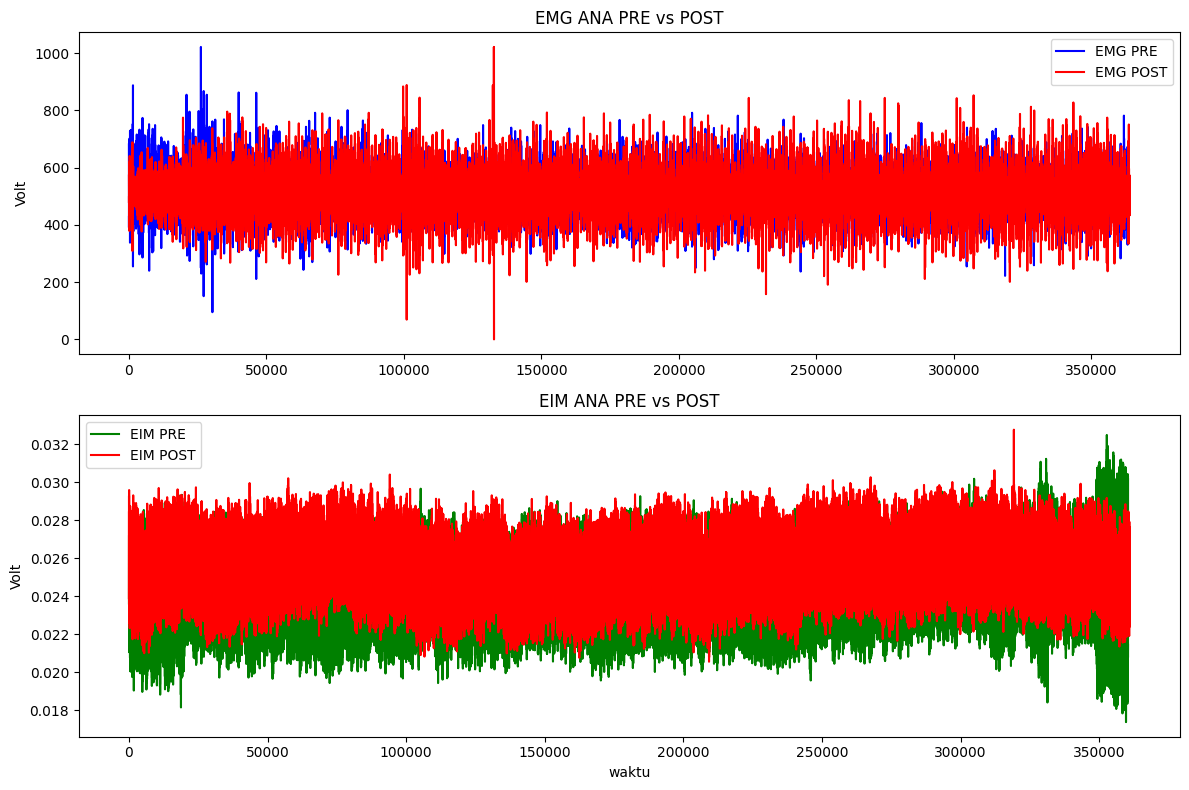

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(12,8))

# EMG
sns.lineplot(ax=ax[0], data=dataEMG["ANA_PRE"], label="EMG PRE", color="blue")
sns.lineplot(ax=ax[0], data=dataEMG["ANA_POST"], label="EMG POST", color="red")
ax[0].set_title("EMG ANA PRE vs POST")
ax[0].set_ylabel("Volt")

# EIM
sns.lineplot(ax=ax[1], data=dataEIM["ANA_PRE"], label="EIM PRE", color="green")
sns.lineplot(ax=ax[1], data=dataEIM["ANA_POST"], label="EIM POST", color="red")
ax[1].set_title("EIM ANA PRE vs POST")
ax[1].set_xlabel("waktu")
ax[1].set_ylabel("Volt")

plt.tight_layout()
plt.show()

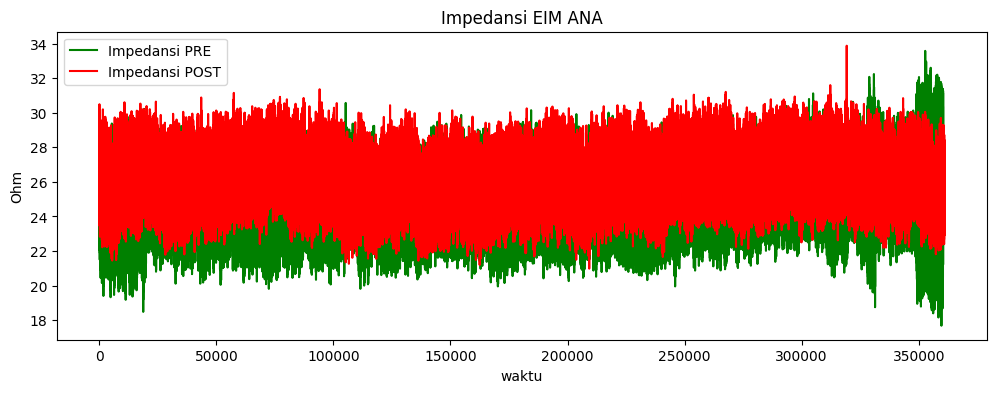

In [8]:
R = 1000
Vin = 1

Z_pre = (R * dataEIM["ANA_PRE"]) / (Vin - dataEIM["ANA_PRE"])
Z_post = (R * dataEIM["ANA_POST"]) / (Vin - dataEIM["ANA_POST"])
plt.figure(figsize=(12,4))

plt.plot(Z_pre, label="Impedansi PRE", color="green")
plt.plot(Z_post, label="Impedansi POST", color="red")

plt.title("Impedansi EIM ANA")
plt.xlabel("waktu")
plt.ylabel("Ohm")

plt.legend()
plt.show()

In [9]:
print(dataEMG.isna().sum().sum())
print(dataEMG.isna().sum())

107100
AMI_PRE     2700
AMI_POST    3450
ANF_PRE      900
ANF_POST    3450
HFN_PRE     2850
HFN_POST    2700
JDS_PRE     1650
JDS_POST    3300
MFD_PRE     1650
MFD_POST    3600
MHA_PRE     3450
MHA_POST    3600
MNA_PRE     2700
MNA_POST    4050
MRA_PRE     1500
MRA_POST    4200
RAR_PRE      300
RAR_POST    3150
RUM_PRE     3450
RUM_POST    2400
ANA_PRE     4050
ANA_POST    3450
CCS_PRE     2700
CCS_POST    2700
DC_PRE      2100
DC_POST     2250
GCD_PRE     3450
GCD_POST    4950
NDA_PRE     3600
NDA_POST    2250
NR_PRE      3900
NR_POST     2550
NSF_PRE      900
NSF_POST    1950
RK_PRE      3150
RK_POST     2100
SA_PRE      2850
SA_POST        0
YAR_PRE      900
YAR_POST    2250
dtype: int64


In [10]:
dataEMG = dataEMG.iloc[:360000]
dataEIM = dataEIM.iloc[:360000]

In [11]:
# Fungsi untuk filter bandpass dan notch
def bandpass_filter(signal, fs=1000, low=30, high=350, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

def notch_filter(signal, fs=1000, freq=50, Q=30):
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, signal)

In [12]:
# Terapkan filter pada data EMG dan EIM
dataEMG_filtered = dataEMG.copy()
for col in dataEMG_filtered.columns:
    signal = dataEMG_filtered[col].values
    signal = bandpass_filter(signal)
    signal = notch_filter(signal)
    dataEMG_filtered[col] = signal

dataEIM_filtered = dataEIM.copy()
for col in dataEIM_filtered.columns:
    signal = dataEIM_filtered[col].values
    signal = notch_filter(signal)
    dataEIM_filtered[col] = signal

In [13]:
# Plot FFT untuk satu kolom
def plot_fft_simple(raw_signal, filtered_signal, fs=1000, title="Signal", xlim=500):
    raw_signal = np.asarray(raw_signal, dtype=float)
    filtered_signal = np.asarray(filtered_signal, dtype=float)

    valid = ~np.isnan(raw_signal) & ~np.isnan(filtered_signal)
    raw_signal = raw_signal[valid]
    filtered_signal = filtered_signal[valid]

    if len(raw_signal) == 0:
        print("Signal kosong.")
        return

    def compute_fft(sig):
        N = len(sig)
        fft_vals = np.fft.rfft(sig)
        fft_mag = np.abs(fft_vals) / N
        freqs = np.fft.rfftfreq(N, d=1/fs)
        return freqs, fft_mag

    f_raw, mag_raw = compute_fft(raw_signal)
    f_filt, mag_filt = compute_fft(filtered_signal)

    plt.figure(figsize=(12,5))
    plt.semilogy(f_raw, mag_raw + 1e-12, label="Before Filter", alpha=0.8)
    plt.semilogy(f_filt, mag_filt + 1e-12, label="After Filter", alpha=0.8)

    plt.title(f"{title} - FFT Spectrum (Log Scale)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (log)")
    plt.xlim(0, xlim)
    plt.legend()
    plt.grid(True)
    plt.show()

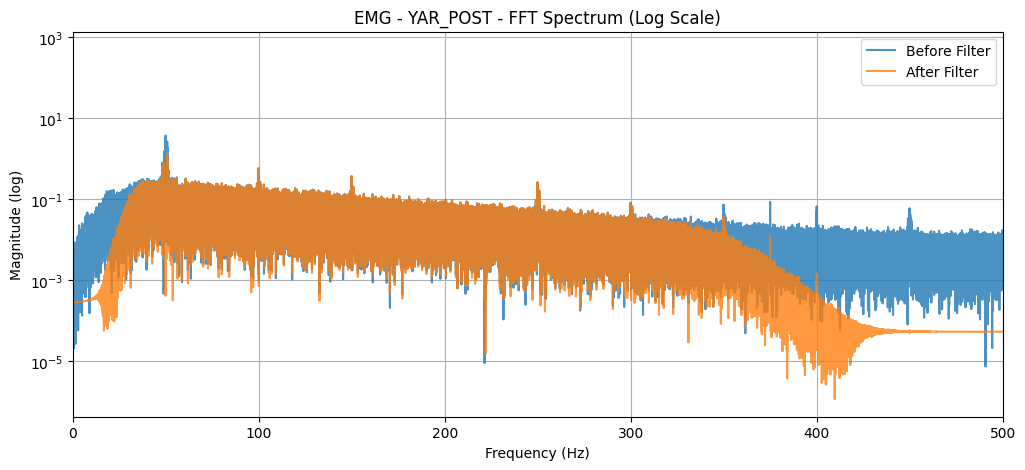

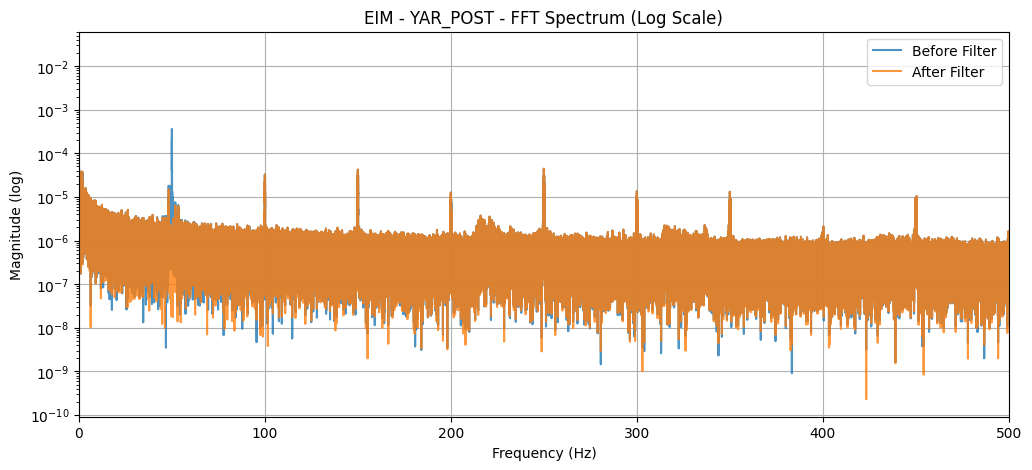

In [14]:
plot_fft_simple(dataEMG["ANA_PRE"], dataEMG_filtered["ANA_PRE"], fs=1000, title=f"EMG - {col}")
plot_fft_simple(dataEIM["ANA_PRE"], dataEIM_filtered["ANA_PRE"], fs=1000, title=f"EIM - {col}")

In [21]:
# Fungsi windowing murni — dipakai oleh semua fungsi lain
def get_windows(signal, fs=1000, window_ms=250, overlap=0.5):
    window_size = int(fs * window_ms / 1000)
    step = int(window_size * (1 - overlap))
    windows = []
    for start in range(0, len(signal) - window_size + 1, step):
        windows.append((start, signal[start:start + window_size]))
    return windows

# Windowing + labeling satu subjek (satu df subset)
def window_and_label(df, fs=1000, window_ms=250, overlap=0.5):
    X, y = [], []
    for col in df.columns:
        signal = df[col].values
        if "PRE" in col:
            label = 0
        elif "POST" in col:
            label = 1
        else:
            continue
        for _, window in get_windows(signal, fs, window_ms, overlap):
            X.append(window)
            y.append(label)
    return np.array(X), np.array(y)

# Visualisasi — pakai get_windows, tidak duplikat logika
def plot_windowing(df, col, fs=1000, window_ms=250, overlap=0.5, n_samples=2500, title_prefix=""):
    signal = pd.to_numeric(df[col], errors='coerce').values[:n_samples]
    windows = get_windows(signal, fs, window_ms, overlap)

    colors = ["red", "blue", "green", "orange", "purple"]
    plt.figure(figsize=(14, 4))
    plt.plot(signal, color="black", linewidth=1, alpha=0.5, label="Full signal")
    for i, (start, window) in enumerate(windows):
        x = np.arange(start, start + len(window))
        plt.plot(x, window, color=colors[i % len(colors)], linewidth=2)
    plt.title(f"{title_prefix} - {col} (Windowing)")
    plt.xlabel("Sample")
    plt.ylabel("Volt")
    plt.grid(True)
    plt.show()

# Ekstrak nama subjek dari nama kolom (misal: "ANA_PRE" → "ANA")
def get_subjects(df):
    subjects = set()
    for col in df.columns:
        if col.endswith("_PRE") or col.endswith("_POST"):
            subject = col.rsplit("_", 1)[0]
            subjects.add(subject)
    return sorted(subjects)


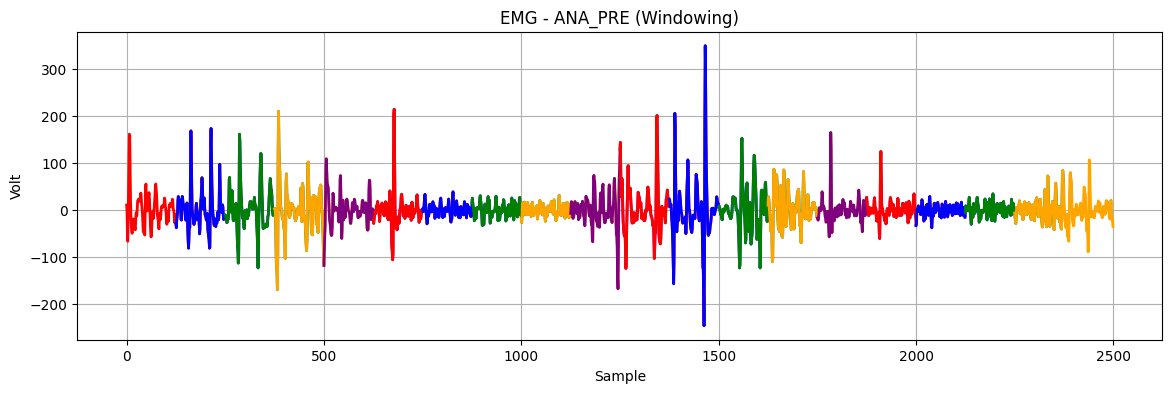

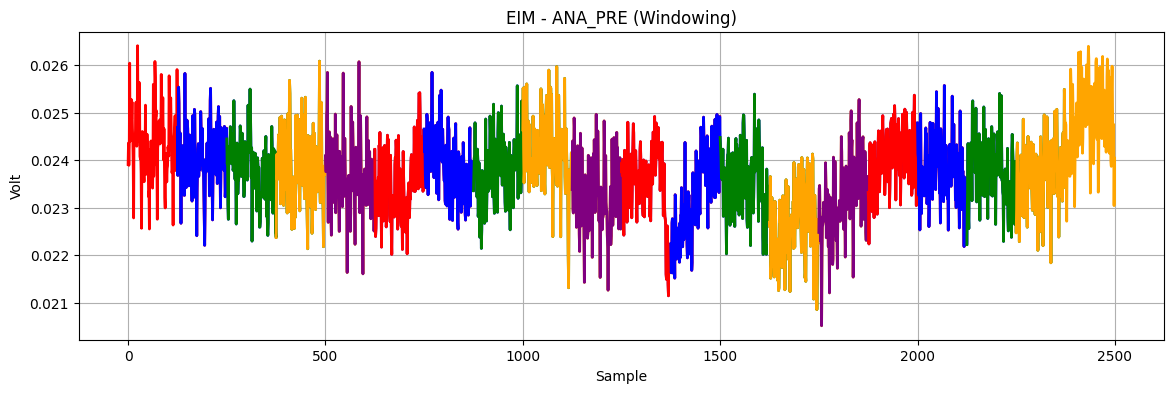

In [20]:
plot_windowing(dataEMG_filtered, "ANA_PRE", title_prefix="EMG")
plot_windowing(dataEIM_filtered, "ANA_PRE", title_prefix="EIM")

In [39]:
X_emgW, y_emgW = window_and_label(dataEMG_filtered)

print("Shape of X_emg (windows):", X_emgW.shape)
print("Shape of y_emg (labels):", y_emgW.shape)

unique_labels, label_counts = np.unique(y_emgW, return_counts=True)
for label, count in zip(unique_labels, label_counts):
    print(f"Label {label}: {count} samples")

Shape of X_emg (windows): (115160, 250)
Shape of y_emg (labels): (115160,)
Label 0: 57580 samples
Label 1: 57580 samples


In [22]:
# FEATURE EXTRACTION
def extract_emg_features(window, fs=1000):
    N = len(window)
    
    # Time domain
    rms  = np.sqrt(np.mean(window**2))
    mav  = np.mean(np.abs(window))
    zc   = np.sum(np.diff(np.sign(window)) != 0)
    wl   = np.sum(np.abs(np.diff(window)))
    ssc  = np.sum(np.diff(np.sign(np.diff(window))) != 0)
    wamp = np.sum(np.abs(np.diff(window)) > 0.01)  # threshold sesuaikan

    # Frequency domain via Welch
    freqs, psd = welch(window, fs=fs, nperseg=min(N, 256))
    total_power = np.sum(psd)
    
    mnp = total_power / len(psd)
    ttp = total_power
    
    # Mean/Median frequency
    cumsum = np.cumsum(psd)
    mnf = np.sum(freqs * psd) / total_power if total_power > 0 else 0
    mdf_idx = np.searchsorted(cumsum, total_power / 2)
    mdf = freqs[mdf_idx] if mdf_idx < len(freqs) else 0
    
    # Frequency ratios
    low_mask  = freqs <= 250
    high_mask = freqs > 250
    pkf = freqs[np.argmax(psd)]
    fr  = np.sum(psd[low_mask]) / np.sum(psd[high_mask]) if np.sum(psd[high_mask]) > 0 else 0

    return np.array([mnf, mdf, fr, pkf, mnp, ttp, rms, mav, zc, wl, ssc, wamp])


def extract_eim_features(window):
    skewness = skew(window)
    kurt     = kurtosis(window)
    
    coeffs   = pywt.cwt(window, scales=np.arange(1, 32), wavelet='morl')[0]
    mean_cwt = np.mean(np.abs(coeffs))
    max_cwt  = np.max(np.abs(coeffs))
    
    return np.array([skewness, kurt, mean_cwt, max_cwt])


# EKSTRAKSI SEMUA FITUR SEBELUM KFOLD
def extract_all_features(df, modality="emg", fs=1000, window_ms=250, overlap=0.5):
    X_feat = []
    y_all  = []
    subjects_all = []

    subjects = get_subjects(df)

    for subj in subjects:
        cols = [c for c in df.columns if c.rsplit("_", 1)[0] == subj]
        for col in cols:
            signal = df[col].values
            label  = 0 if "PRE" in col else 1

            for _, window in get_windows(signal, fs, window_ms, overlap):
                if modality == "emg":
                    feat = extract_emg_features(window, fs)
                else:
                    feat = extract_eim_features(window)
                
                X_feat.append(feat)
                y_all.append(label)
                subjects_all.append(subj)

    return np.array(X_feat), np.array(y_all), np.array(subjects_all)

In [27]:
X_emg_feat, y_emg, subj_emg = extract_all_features(dataEMG_filtered, modality="emg")
X_eim_feat, y_eim, subj_eim = extract_all_features(dataEIM_filtered, modality="eim")

print(X_emg_feat.shape)  # (n_windows, 12)
print(X_eim_feat.shape)  # (n_windows, 4)

(115160, 12)
(115160, 4)


In [38]:
# RESERVOIR COMPUTING (ESN)
def run_esn(X_train, X_test, y_train, y_test,
            units=1200, sr=0.99, lr=0.3, ridge=1.0,
            rc_connectivity=0.25, input_scaling=0.15):

    reservoir = Reservoir(
        units=units, sr=sr, lr=lr,
        rc_connectivity=rc_connectivity,
        input_scaling=input_scaling
    )
    readout = Ridge(ridge=ridge)

    # Setiap sample sebagai list of 2D arrays (1 timestep × n_features)
    # ReservoirPy 0.4.1: tiap series dijalankan dari zero state secara independen
    raw_train = reservoir.run([x.reshape(1, -1) for x in X_train])
    states_train = np.array([s[-1] for s in raw_train])   # ambil last (satu-satunya) timestep

    readout.fit(states_train, y_train.reshape(-1, 1))

    raw_test = reservoir.run([x.reshape(1, -1) for x in X_test])
    states_test = np.array([s[-1] for s in raw_test])

    y_prob = readout.run(states_test).flatten()
    y_pred = (y_prob > 0.5).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)

    return acc, prec, rec, f1, auc, y_pred, y_prob


# K-Fold Cross Validation per subjek
subjects = np.array(get_subjects(dataEMG_filtered))
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {
    s: {"acc": [], "prec": [], "rec": [], "f1": [], "auc": []}
    for s in ["emg", "eim", "fused"]
}

for fold, (train_idx, test_idx) in enumerate(kf.split(subjects)):
    train_subj = subjects[train_idx]
    test_subj  = subjects[test_idx]

    train_mask = np.isin(subj_emg, train_subj)
    test_mask  = np.isin(subj_emg, test_subj)

    X_train_emg, X_test_emg = X_emg_feat[train_mask], X_emg_feat[test_mask]
    X_train_eim, X_test_eim = X_eim_feat[train_mask], X_eim_feat[test_mask]
    y_train = y_emg[train_mask]
    y_test  = y_emg[test_mask]

    # Scaler — fit on train only
    scaler_emg = StandardScaler().fit(X_train_emg)
    X_train_emg = scaler_emg.transform(X_train_emg)
    X_test_emg  = scaler_emg.transform(X_test_emg)

    scaler_eim = StandardScaler().fit(X_train_eim)
    X_train_eim = scaler_eim.transform(X_train_eim)
    X_test_eim  = scaler_eim.transform(X_test_eim)

    X_train_fused = np.hstack([X_train_emg, X_train_eim])
    X_test_fused  = np.hstack([X_test_emg,  X_test_eim])

    # PCA — fit on train only
    # pca_emg = PCA(n_components=0.95).fit(X_train_emg)
    # X_train_emg_pca = pca_emg.transform(X_train_emg)
    # X_test_emg_pca  = pca_emg.transform(X_test_emg)

    # pca_eim = PCA(n_components=0.95).fit(X_train_eim)
    # X_train_eim_pca = pca_eim.transform(X_train_eim)
    # X_test_eim_pca  = pca_eim.transform(X_test_eim)

    # pca_fused = PCA(n_components=0.95).fit(X_train_fused)
    # X_train_fused_pca = pca_fused.transform(X_train_fused)
    # X_test_fused_pca  = pca_fused.transform(X_test_fused)

    # print(f"\nFold {fold+1}")
    # print(f"  PCA components  — EMG: {pca_emg.n_components_} | EIM: {pca_eim.n_components_} | Fused: {pca_fused.n_components_}")
    # print(f"  Train: {X_train_emg_pca.shape[0]} samples | Test: {X_test_emg_pca.shape[0]} samples")

    # r_emg   = run_esn(X_train_emg_pca,   X_test_emg_pca,   y_train, y_test)
    # r_eim   = run_esn(X_train_eim_pca,   X_test_eim_pca,   y_train, y_test)
    # r_fused = run_esn(X_train_fused_pca, X_test_fused_pca, y_train, y_test)
    r_emg   = run_esn(X_train_emg,   X_test_emg,   y_train, y_test)
    r_eim   = run_esn(X_train_eim,   X_test_eim,   y_train, y_test)
    r_fused = run_esn(X_train_fused, X_test_fused, y_train, y_test)

    header = f"  {'':8} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}"
    print(header)
    for name, r in [("EMG", r_emg), ("EIM", r_eim), ("Fused", r_fused)]:
        acc, prec, rec, f1, auc, _, _ = r
        print(f"  {name:8} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {auc:>7.4f}")

    for key, r in zip(["emg", "eim", "fused"], [r_emg, r_eim, r_fused]):
        acc, prec, rec, f1, auc, _, _ = r
        results[key]["acc"].append(acc)
        results[key]["prec"].append(prec)
        results[key]["rec"].append(rec)
        results[key]["f1"].append(f1)
        results[key]["auc"].append(auc)

# Summary
print("\n" + "="*55)
print("RINGKASAN 5-FOLD CROSS VALIDATION")
print("="*55)
for scenario in ["emg", "eim", "fused"]:
    print(f"\n{scenario.upper()}")
    for metric in ["acc", "prec", "rec", "f1", "auc"]:
        vals = results[scenario][metric]
        print(f"  {metric:6}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

               Acc    Prec     Rec      F1     AUC
  EMG       0.6438  0.6656  0.5778  0.6186  0.7020
  EIM       0.5213  0.5251  0.4462  0.4825  0.5294
  Fused     0.6309  0.7250  0.4218  0.5333  0.6975
               Acc    Prec     Rec      F1     AUC
  EMG       0.4701  0.4727  0.5179  0.4943  0.4794
  EIM       0.4960  0.4956  0.4513  0.4724  0.5914
  Fused     0.4590  0.4760  0.8124  0.6003  0.5094
               Acc    Prec     Rec      F1     AUC
  EMG       0.4916  0.4948  0.7943  0.6097  0.5220
  EIM       0.5726  0.5622  0.6558  0.6054  0.5735
  Fused     0.4600  0.4790  0.9142  0.6286  0.5390
               Acc    Prec     Rec      F1     AUC
  EMG       0.6226  0.6653  0.4935  0.5667  0.6805
  EIM       0.4900  0.1577  0.0046  0.0089  0.4757
  Fused     0.4979  0.3333  0.0043  0.0084  0.5664
               Acc    Prec     Rec      F1     AUC
  EMG       0.5391  0.5210  0.9701  0.6779  0.6700
  EIM       0.5279  0.5405  0.3718  0.4406  0.5943
  Fused     0.5174  0.5089  0.9